# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Setup: Clone the Data Repository

Before starting, you need to clone the course data repository to access the datasets:

```bash
git clone https://github.com/noise-courses/data.git
```

This repository contains the Netflix packet capture needed for this assignment in the `data/video-qoe/` directory.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file from `data/video-qoe/netflix.pcap`, which is a packet trace that includes network traffic.

Name: Aeliya Grover 
CNET: aeliyag
Used Cursor as an LLM coding assistant

In [43]:
import logging
from scapy.all import DNS, DNSQR
from scapy.utils import rdpcap
from netml.pparser.parser import PCAP

logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

pcap = PCAP('data/video-qoe/netflix.pcap', flow_ptks_thres=2, verbose=10)
all_pkts = rdpcap('data/video-qoe/netflix.pcap')

pcap.pcap2flows()   # convert packets into flows

pcap_file: data/video-qoe/netflix.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
ith_packets: 30000
ith_packets: 40000
ith_packets: 50000
ith_packets: 60000
ith_packets: 70000
ith_packets: 80000
ith_packets: 90000
ith_packets: 100000
ith_packets: 110000
ith_packets: 120000
ith_packets: 130000
ith_packets: 140000
len(flows): 275
total number of flows: 275. Num of flows < 2 pkts: 91, and >=2 pkts: 184 without timeout splitting.
kept flows: 184. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (184, 1)
        col_0
count 184.000
mean   82.331
std   127.700
min     1.138
25%    14.428
50%    17.122
75%    71.087
max   486.705
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   184 non-null    float64
dtypes: float64(1)
memory usage: 1.6 KB
None
0th_flow: len(pkts): 12
After splitting flows, the number of subflo

### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

We identify Netflix traffic by finding DNS queries for Netflix-related domains, matching responses via transaction ID to get CDN IP addresses, then keeping flows where source or destination is one of those IPs.

DNS query - When a device wants to reach a hostname like nflxvideo.netflix.com, it first asks a DNS server what IP address the name maps to. This request is a DNS query 

Domains - hostnames that belong to Netflix's infrasturcture 

DNS response - DNS server answer to a query. Will contain one or more A records (IPv4 addresses)

Transaction ID - ID number that pairs each DNS message with its query response 

CDN - content delivery network. When DNS resolves a Netflix domain, it returns the IP of a nerby CDN server to feed video content from.



In [44]:
NF_DOMAINS = ["nflxvideo", "netflix", "nflxso", "nflxext"]
DNS_TYPE_A = 1  # A record = IPv4 address

# Checks if the domain is a netflix domain
# @param qname: the domain name
# @return: True if the domain is a netflix domain, False otherwise
def is_netflix_domain(qname):
    name = qname.decode() if isinstance(qname, bytes) else str(qname)
    return any(d in name.lower() for d in NF_DOMAINS)

# Normalizes the ip address
# @param rdata: the ip address
# @return: the normalized ip address
def normalize_ip(rdata):
    return rdata.decode() if isinstance(rdata, bytes) else str(rdata)

# Set of unique Netflix query IDs and IPs
netflix_query_ids = set()
netflix_ips = set()

# Iterating through all the packets
for pkt in all_pkts:
    if not pkt.haslayer(DNS):
        continue

    dns = pkt[DNS]

    if dns.qr == 0 and pkt.haslayer(DNSQR):   # Checks if the packet is a DNS query
        if is_netflix_domain(dns[DNSQR].qname):
            netflix_query_ids.add(dns.id)

    elif dns.qr == 1 and dns.id in netflix_query_ids:   # Checks if the packet is a DNS response
        for i in range(dns.ancount):
            rr = dns.an[i]
            if rr.type == DNS_TYPE_A:
                netflix_ips.add(normalize_ip(rr.rdata))

print(f"Found {len(netflix_query_ids)} Netflix DNS query IDs")
print(f"Found {len(netflix_ips)} Netflix IP addresses:")
print(netflix_ips)

# Checks if the flow is a netflex flow 
# @param flow_key: the flow key
# @param netflix_ips: the set of netflix ips
# @return: True if the flow is a netflix flow, False otherwise
def is_netflix_flow(flow_key, netflix_ips):
    src_ip, dst_ip = flow_key[0], flow_key[1]
    return src_ip in netflix_ips or dst_ip in netflix_ips

if isinstance(pcap.flows, dict):
    flow_items = pcap.flows.items()
else:
    flow_items = pcap.flows  # assume list of (flow_key, pkts) tuples

netflix_flows = [
    (flow_key, pkts)
    for flow_key, pkts in flow_items
    if is_netflix_flow(flow_key, netflix_ips)
]

netflix_pkts = sum(len(pkts) for _, pkts in netflix_flows)
all_flow_pkts = sum(len(pkts) for _, pkts in flow_items)

print(f"{len(netflix_flows)} Netflix flows out of {len(list(flow_items))} total")
print(f"{netflix_pkts} Netflix packets out of {all_flow_pkts} packets in all flows")

Found 17 Netflix DNS query IDs
Found 16 Netflix IP addresses:
{'198.38.120.130', '198.38.120.153', '52.210.133.255', '52.210.19.176', '198.38.120.134', '52.48.148.78', '198.38.120.162', '198.38.120.164', '52.19.39.146', '198.38.120.167', '34.252.77.54', '198.38.120.137', '23.57.80.120', '52.208.128.101', '52.48.8.150', '198.38.120.166'}
138 Netflix flows out of 184 total
140472 Netflix packets out of 141284 packets in all flows


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [45]:
original_flows = pcap.flows # Storing the original flows
pcap.flows = netflix_flows # Setting the flows to the netflix flows

In [46]:
import pandas as pd
# summary stats 
pcap.flow2features('STATS', fft=False, header=False)
stats_features = pd.DataFrame(pcap.features)
print("STATS shape:", stats_features.shape)
display(stats_features.head())

# byte counts per time window
pcap.flow2features('SAMP_SIZE', fft=False, header=False)
samp_size_features = pd.DataFrame(pcap.features)
print("SAMP_SIZE shape:", samp_size_features.shape)

# packet counts per time window
pcap.flow2features('SAMP_NUM', fft=False, header=False)
samp_num_features = pd.DataFrame(pcap.features)
print("SAMP_NUM shape:", samp_num_features.shape)

# inter-arrival times between consecutive packets
pcap.flow2features('IAT', fft=False, header=False)
iat_features = pd.DataFrame(pcap.features)
print("IAT shape:", iat_features.shape)

True
STATS shape: (138, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,14.440,0.831,73.683,88.667,48.141,66.000,66.000,69.000,66.000,200.000,12.000,1064.000
1,14.443,0.762,69.100,90.727,49.772,66.000,66.000,72.000,66.000,200.000,11.000,998.000
2,14.437,0.831,73.697,88.667,48.141,66.000,66.000,69.000,66.000,200.000,12.000,1064.000
3,138.855,1.498,184.560,123.207,66.444,66.000,66.000,200.000,54.000,200.000,208.000,25627.000
4,74.818,0.361,45.203,125.259,66.351,66.000,66.000,200.000,54.000,200.000,27.000,3382.000


True
SAMP_SIZE shape: (138, 740)
True
SAMP_NUM shape: (138, 740)
True
IAT shape: (138, 740)


**Write a brief justification for the features that you have chosen.**

### Why We Chose These Features

**Problem constraint:** Netflix video is delivered over encrypted HTTPS, so we cannot read video content, URLs, or filenames. We only have packet metadata: timing, sizes, and counts.

**Feature selection strategy:** We chose features that mirror how Netflix streaming behaves on the network:

- **STATS** — captures overall flow intensity (bytes/sec, packets/sec, packet size distribution). Higher resolution streams typically require higher throughput.
- **SAMP_SIZE** — captures byte counts in fixed time windows. Adaptive bitrate (ABR) ramps quality up/down over time.
- **SAMP_NUM** — captures packet counts per time window. Segment downloads appear as bursty traffic.
- **IAT** — captures inter-arrival times between consecutive packets. Reveals fine-grained pacing and pauses between bursts (e.g., buffering gaps).
- **Segment download rate** — counts video chunks per time window, using the same windows as the SAMP features so it can be appended directly to the `SAMP_SIZE` matrix. Only downstream (CDN → client) traffic is counted, since that is what carries video.

**What we deliberately avoided:** Features that require decrypting content, or that leak the label (e.g., resolution switch counts).

All of these are observable from packet metadata without decrypting video content, which matches the ISP/infrastructure inference setting from class.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

TCP (Transmission Control Protocol) is the transport protocol that reliably delivers data over the internet. Video bytes travel inside TCP packets, each with headers and a payload (actual data).

Because Netflix traffic is encrypted, we cannot see URLs or filenames. We infer segment downloads from packet metadata. Netflix sends video in chunks (segments), which appear on the network as bursts of downstream data separated by idle gaps (packets with zero payload, e.g. ACKs).

Our approach:

1. For each flow, sort packets by time.
2. Treat payload > 0 as data; payload = 0 as a gap.
3. Count a new segment when payload resumes after a gap.
4. Only count downstream flows (CDN → client), where the source IP is a Netflix CDN IP.
5. Bin segment start times into the same time windows as SAMP_SIZE and compute segment download rate (segments started per window / window length).

This gives a feature that reflects how aggressively video chunks are being fetched, without decrypting the content.

In [47]:
from scapy.all import TCP
import pandas as pd
import numpy as np

# Returns the TCP payload size in bytes (0 for pure ACKs / control packets)
# @param pkt: the packet
# @return: the payload size in bytes
def tcp_payload_len(pkt):
    return len(bytes(pkt[TCP].payload)) if pkt.haslayer(TCP) else 0

# A segment download starts when payload resumes after an idle gap
# @param pkts: the packets of one flow
# @return: the timestamps where a new segment begins
def segment_start_times(pkts):
    starts = []
    in_segment = False
    for pkt in sorted(pkts, key=lambda p: float(p.time)):
        if tcp_payload_len(pkt) > 0:
            if not in_segment:
                starts.append(float(pkt.time))
            in_segment = True
        else:
            in_segment = False
    return starts

# Segments started per second, one value per time window of the flow
# @param pkts: the packets of one flow
# @param is_downstream: True if the flow is CDN -> client
# @param window: the window length in seconds
# @param n_windows: the number of windows (matches the SAMP feature width)
# @return: the segment download rate per window
def segment_download_rate(pkts, is_downstream, window, n_windows):
    # only CDN -> client traffic carries video segments
    if not is_downstream:
        return np.zeros(n_windows)

    starts = segment_start_times(pkts)
    if not starts:
        return np.zeros(n_windows)

    t0 = min(float(p.time) for p in pkts)
    slots = ((np.array(starts) - t0) // window).astype(int)
    counts = np.bincount(slots, minlength=n_windows)[:n_windows]
    return counts / window


# Match the window netml uses for SAMP features: the 0.3 quantile of flow durations
durations = [
    max(float(p.time) for p in pkts) - min(float(p.time) for p in pkts)
    for _, pkts in netflix_flows
]
window = float(np.quantile(durations, 0.3))
n_windows = samp_size_features.shape[1]
print(f"SAMP window: {window:.2f}s x {n_windows} windows")

# One row per flow, aligned with the SAMP_SIZE rows
segment_rate_features = pd.DataFrame(
    [
        segment_download_rate(pkts, fid[0] in netflix_ips, window, n_windows)
        for fid, pkts in netflix_flows
    ],
    columns=[f"seg_rate_{i}" for i in range(n_windows)],
)

# Segment counts per downstream flow, reused for the totals below
downstream_flows = [(fid, pkts) for fid, pkts in netflix_flows if fid[0] in netflix_ips]
segment_counts = pd.DataFrame(
    [(fid[0], len(segment_start_times(pkts))) for fid, pkts in downstream_flows],
    columns=["netflix_ip", "segments"],
)
print(f"Downstream flows: {len(downstream_flows)} of {len(netflix_flows)}")
print(f"Total segment downloads detected: {segment_counts['segments'].sum()}")

# Add the segment download rate to the existing SAMP_SIZE dataframe
samp_size_with_segments = pd.concat(
    [samp_size_features.reset_index(drop=True), segment_rate_features],
    axis=1,
)
print("SAMP_SIZE shape:", samp_size_features.shape)
print("Combined shape:", samp_size_with_segments.shape)

# Sanity check: segments per CDN IP
print("\nSegments per Netflix CDN IP:")
print(segment_counts.groupby("netflix_ip")["segments"].sum().sort_values(ascending=False))


SAMP window: 14.47s x 740 windows
Downstream flows: 69 of 138
Total segment downloads detected: 138
SAMP_SIZE shape: (138, 740)
Combined shape: (138, 1480)

Segments per Netflix CDN IP:
netflix_ip
52.19.39.146      40
198.38.120.164    18
198.38.120.166    17
23.57.80.120      15
52.210.19.176     11
52.208.128.101     9
198.38.120.153     6
198.38.120.162     6
198.38.120.167     4
198.38.120.130     3
198.38.120.137     3
34.252.77.54       3
198.38.120.134     2
52.48.148.78       1
Name: segments, dtype: int64


**Result:** 69 of the 138 Netflix flows are downstream (CDN → client), and we detect 138 segment downloads across them. The segment-rate columns use the same window length and layout as the SAMP features, so they append directly onto `SAMP_SIZE` for a combined matrix of 138 flows × 1480 features.


## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

Two datasets are available in the data repository:

1. **netflix_dataset.pkl** (52,279 samples, 251 features) - Netflix-only data
2. **video_dataset.pkl** (204,713 samples, 170 features) - Multi-service data (Netflix, YouTube, Twitch, Amazon Prime)

Decompress the dataset you want to use:

```bash
# Option 1: Netflix-only dataset (105 MB uncompressed)
xz -d data/video-qoe/netflix_dataset.pkl.xz

# Option 2: Multi-service dataset (265 MB uncompressed)
xz -d data/video-qoe/video_dataset.pkl.xz
```

You can use either dataset for this assignment. The multi-service dataset has more samples but fewer features.

### Load the File

Load the video dataset pickle file.

In [48]:
import pandas as pd
import numpy as np

DATA_PATH = "data/video-qoe/netflix_dataset.pkl"

df = pd.read_pickle(DATA_PATH)

print(df.shape)
df.head()

(52279, 251)


,10_EWMA_chunksizes,10_avg_chunksize,10_chunksizes_50,10_chunksizes_50R,10_chunksizes_75,10_chunksizes_75R,10_chunksizes_85,10_chunksizes_85R,10_chunksizes_90,10_chunksizes_90R,10_max_chunksize,10_min_chunksize,10_std_chunksize,absolute_timestamp,access_50_perc,access_75_perc,access_avg,access_max,access_min,access_stddev,access_var,ads,all_prev_down_chunk_iat_50,all_prev_down_chunk_iat_50R,all_prev_down_chunk_iat_75,all_prev_down_chunk_iat_75R,all_prev_down_chunk_iat_85,all_prev_down_chunk_iat_85R,all_prev_down_chunk_iat_90,all_prev_down_chunk_iat_90R,all_prev_down_chunk_iat_avg,all_prev_down_chunk_iat_max,all_prev_down_chunk_iat_min,all_prev_down_chunk_iat_std,all_prev_up_chunk_iat_50,all_prev_up_chunk_iat_50R,all_prev_up_chunk_iat_75,all_prev_up_chunk_iat_75R,all_prev_up_chunk_iat_85,all_prev_up_chunk_iat_85R,all_prev_up_chunk_iat_90,all_prev_up_chunk_iat_90R,all_prev_up_chunk_iat_avg,all_prev_up_chunk_iat_max,all_prev_up_chunk_iat_min,all_prev_up_chunk_iat_std,allprev_avg_chunksize,allprev_chunksizes_50,allprev_chunksizes_50R,allprev_chunksizes_75,allprev_chunksizes_75R,allprev_chunksizes_85,allprev_chunksizes_85R,allprev_chunksizes_90,allprev_chunksizes_90R,allprev_max_chunksize,allprev_min_chunksize,allprev_std_chunksize,avg_flow_age,bitrate,bitrate_change,c_bitrate_switches,c_rebufferings,c_resolution_switches,chunk_end_time,chunk_start_time,cumsum_chunksizes,cumsum_diff,curr_chunksize,current_chunk_iat,deployment_session_id,down_chunk_iat_50,down_chunk_iat_50R,down_chunk_iat_75,down_chunk_iat_75R,down_chunk_iat_85,down_chunk_iat_85R,down_chunk_iat_90,down_chunk_iat_90R,down_chunk_iat_avg,down_chunk_iat_max,down_chunk_iat_min,down_chunk_iat_std,home_id,index,is_tcp,n_bitrate_switches,n_chunks_down,n_chunks_up,n_prev_down_chunk,n_prev_up_chunk,n_rebufferings,parallel_flows,previous_bitrate,quality,relative_timestamp,resolution,service_Video_throughput_down,service_Video_throughput_up,service_non_video_throughput_down,service_non_video_throughput_up,session_id,size_diff_previous,startup_time,total_throughput_down,total_throughput_up,up_chunk_iat_50,up_chunk_iat_50R,up_chunk_iat_75,up_chunk_iat_75R,up_chunk_iat_85,up_chunk_iat_85R,up_chunk_iat_90,up_chunk_iat_90R,up_chunk_iat_avg,up_chunk_iat_max,up_chunk_iat_min,up_chunk_iat_std,up_down_ratio,video_duration,video_id,video_position,wireless_50_perc,wireless_75_perc,wireless_avg,wireless_max,wireless_min,wireless_stddev,wireless_var,serverAckFlags,serverAvgBytesInFlight,serverAvgBytesPerPacket,serverAvgInterArrivalTime,serverAvgRetransmit,serverAvgRwnd,serverBitrateChange,serverByteCount,serverEndBytesPerPacket,serverFinFlags,serverGoodput,serverIdleTime,serverKurBytesInFlight,serverKurBytesPerPacket,serverKurInterArrivalTime,serverKurRetransmit,serverKurRwnd,serverMaxBytesInFlight,serverMaxBytesPerPacket,serverMaxInterArrivalTime,serverMaxRetransmit,serverMaxRwnd,serverMedBytesInFlight,serverMedBytesPerPacket,serverMedInterArrivalTime,serverMedRetransmit,serverMedRwnd,serverMinBytesInFlight,serverMinBytesPerPacket,serverMinInterArrivalTime,serverMinRetransmit,serverMinRwnd,serverOneRetransmit,serverOutOfOrderBytes,serverOutOfOrderPackets,serverPacketCount,serverPshFlags,serverRstFlags,serverSkeBytesInFlight,serverSkeBytesPerPacket,serverSkeInterArrivalTime,serverSkeRetransmit,serverSkeRwnd,serverStdBytesInFlight,serverStdBytesPerPacket,serverStdInterArrivalTime,serverStdRetransmit,serverStdRwnd,serverStrBytesPerPacket,serverSynFlags,serverThroughput,serverTwoRetransmit,serverUrgFlags,serverXRetransmit,serverZeroRetransmit,userAckFlags,userAvgBytesInFlight,userAvgBytesPerPacket,userAvgInterArrivalTime,userAvgRTT,userAvgRetransmit,userAvgRwnd,userByteCount,userEndBytesInFlight,userFinFlags,userGoodput,userIdleTime,userKurBytesInFlight,userKurBytesPerPacket,userKurInterArrivalTime,userKurRTT,userKurRetransmit,userKurRwnd,userMaxBytesInFlight,userMaxBytesPerPacket,userMaxInterArrivalTime,userMaxRTT,userMaxRetransmit,userMaxRwnd,userMedBytesInFlight,userMedBytesPerPacket,userMe

### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [49]:
VALID_RESOLUTIONS = [240, 360, 480, 720, 1080]

print("Before:", df.shape)
print(df["resolution"].value_counts().sort_index())

df = df[df["resolution"].isin(VALID_RESOLUTIONS)].copy()

print("After:", df.shape)
print(df["resolution"].value_counts().sort_index())

Before: (52279, 251)
resolution
0.000        2531
240.000      1701
360.000      4476
480.000     29486
720.000      9457
1080.000     4628
Name: count, dtype: int64
After: (49748, 251)
resolution
240.000      1701
360.000      4476
480.000     29486
720.000      9457
1080.000     4628
Name: count, dtype: int64


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [50]:
DROP_COLS = [
    "resolution",              # label
    "index",                   # row index
    "absolute_timestamp",
    "relative_timestamp",
    "chunk_start_time",
    "chunk_end_time",
    "deployment_session_id",
    "session_id",
    "home_id",
    "video_id",
    "service",                 # constant in netflix_dataset
    "c_resolution_switches",   # leaky (resolution-change count)
    "10_EWMA_chunksizes",      # nested arrays; sklearn needs flat numeric features
]

DROP_COLS = [c for c in DROP_COLS if c in df.columns]

y = df["resolution"].astype(int)
X = df.drop(columns=DROP_COLS)

# one-hot encode the remaining non-numeric column(s)
X = pd.get_dummies(X, columns=[c for c in X.select_dtypes(include="object").columns])

# fill missing values so RandomForest can train
X = X.fillna(X.median(numeric_only=True))

print("Features:", X.shape)
print("Label distribution:\n", y.value_counts().sort_index())


Features: (49748, 239)
Label distribution:
 resolution
240      1701
360      4476
480     29486
720      9457
1080     4628
Name: count, dtype: int64


**Briefly explain why you removed those columns.**

We removed columns that are not useful predictors or would leak label information:

- **IDs** (`session_id`, `video_id`, etc.): identifiers, not generalizable features
- **Timestamps**: absolute/relative time does not predict resolution and encourages overfitting
- **`resolution`**: this is the label we are predicting
- **`c_resolution_switches`**: directly related to resolution changes (label leakage)
- **`service`**: constant for this Netflix-only dataset
- **`10_EWMA_chunksizes`**: nested array values; kept flat numeric features for scikit-learn

We one-hot encoded **`quality`** (`good`/`bad`) and filled missing numeric values with column medians.


### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # keep class balance (480 is most common)
)

print(X_train.shape, X_test.shape)


(39798, 239) (9950, 239)


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 40],
    "min_samples_leaf": [1, 2, 5],
}

search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best params:", search.best_params_)

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Accuracy: 0.9641206030150754
F1 (macro): 0.9074114637076617

Classification report:
               precision    recall  f1-score   support

         240       0.84      0.61      0.71       340
         360       0.92      0.84      0.88       895
         480       0.96      0.99      0.98      5897
         720       0.99      0.99      0.99      1892
        1080       0.97      0.99      0.98       926

    accuracy                           0.96      9950
   macro avg       0.94      0.88      0.91      9950
weighted avg       0.96      0.96      0.96      9950

Confusion matrix:
 [[ 208   39   93    0    0]
 [  20  754  121    0    0]
 [  20   27 5845    3    2]
 [   0    0    0 1869   23]
 [   0    0    0    9  917]]
ROC AUC (macro, ovr): 0.9962145862205904


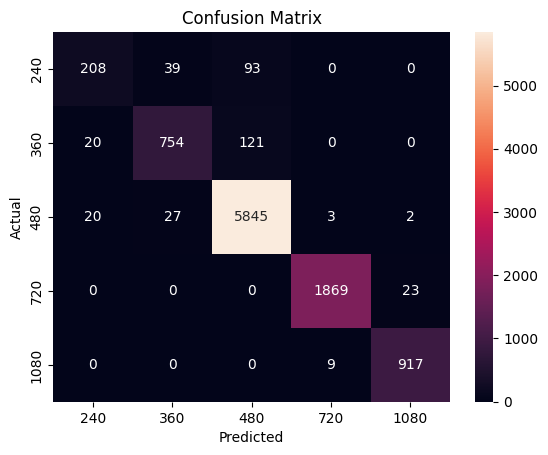

In [54]:
# Evaluating the model
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score
)

from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_model.predict(X_test)

# Printing the accuracy, F1 score, and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (macro):", f1_score(y_test, y_pred, average="macro"))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# ROC/AUC (multi-class, one-vs-rest)
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_model.predict_proba(X_test)

auc = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print("ROC AUC (macro, ovr):", auc)

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Feature Leakage Analysis

Some features in the dataset encode information that's directly derived from or closely correlated with the target label (resolution):

**Explicit metadata (tested here):**
- `bitrate`, `previous_bitrate`, `bitrate_change` — video bitrate values
- `c_bitrate_switches`, `n_bitrate_switches` — bitrate transition counts
- `quality_good` / `quality_bad` — quality labels (one-hot encoded)

**Other potential proxies (still present):**
- `*chunksize*` features — encode segment size in bytes, which correlates with resolution
- Chunk timing features — depend on labeled chunk boundaries

We retrain the model without explicit bitrate and quality metadata to test how much these columns contribute to performance. Note that many chunk-size features remain in both models, so this is a partial ablation.

Leaky features to remove (84 total):
  - Bitrate features: ['bitrate', 'previous_bitrate', 'bitrate_change', 'c_bitrate_switches', 'n_bitrate_switches']
  - Quality features: ['quality_bad', 'quality_good']
  - Chunksize features: 26 features
  - Chunk timing features: ['current_chunk_iat', 'cumsum_diff']
  - Chunk IAT features: 49 features

Original features: 239, After removing leaky features: 156

=== RESULTS WITHOUT BITRATE FEATURES ===
Accuracy: 0.8880402010050251
F1 (macro): 0.8197206542360107

Classification report:
               precision    recall  f1-score   support

         240       0.79      0.45      0.57       340
         360       0.90      0.77      0.83       895
         480       0.87      0.97      0.92      5897
         720       0.91      0.71      0.80      1892
        1080       0.96      0.99      0.98       926

    accuracy                           0.89      9950
   macro avg       0.89      0.78      0.82      9950
weighted avg       0.89      0.89   

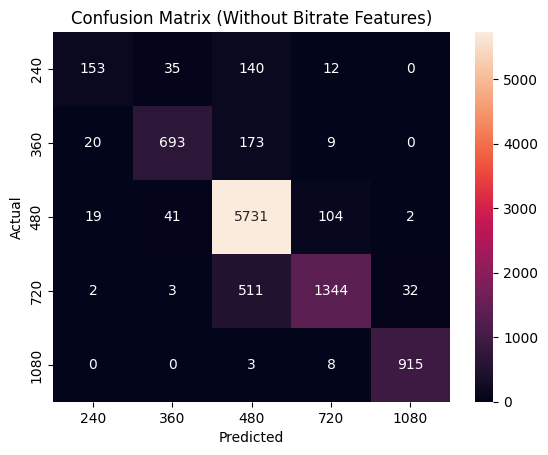


=== COMPARISON ===
Original model accuracy: 0.9641
Without bitrate features: 0.8880
Difference: 0.0761

Original model F1 (macro): 0.9074
Without bitrate features: 0.8197
Difference: 0.0877


In [55]:
# Identify explicit bitrate features to remove
BITRATE_COLS = [
    "bitrate",
    "previous_bitrate",
    "bitrate_change",
    "c_bitrate_switches",
    "n_bitrate_switches",
]

# Chunk timing features (depend on labeled chunk boundaries)
CHUNK_TIMING_COLS = [
    "chunk_start_time",
    "chunk_end_time",
    "current_chunk_iat",
    "cumsum_diff",
]

# quality was one-hot encoded to quality_good / quality_bad
quality_cols = [c for c in X.columns if c.startswith("quality_")]

# Chunksize features (encode segment size in bytes, correlates with resolution)
chunksize_cols = [c for c in X.columns if "chunksize" in c.lower()]

# IAT features related to chunks (inter-arrival times)
chunk_iat_cols = [c for c in X.columns if "chunk_iat" in c.lower()]

# Combine all leaky features
leaky_features = (
    [c for c in BITRATE_COLS if c in X.columns] +
    [c for c in CHUNK_TIMING_COLS if c in X.columns] +
    quality_cols +
    chunksize_cols +
    chunk_iat_cols
)

print(f"Leaky features to remove ({len(leaky_features)} total):")
print(f"  - Bitrate features: {[c for c in BITRATE_COLS if c in X.columns]}")
print(f"  - Quality features: {quality_cols}")
print(f"  - Chunksize features: {len(chunksize_cols)} features")
print(f"  - Chunk timing features: {[c for c in CHUNK_TIMING_COLS if c in X.columns]}")
print(f"  - Chunk IAT features: {len(chunk_iat_cols)} features")

# Create feature matrix without leaky features
X_no_bitrate = X.drop(columns=leaky_features)
print(f"\nOriginal features: {X.shape[1]}, After removing leaky features: {X_no_bitrate.shape[1]}")

# Use the same train/test split for fair comparison
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_no_bitrate, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Train a RandomForest with the same hyperparameters as the best model
model_no_bitrate = RandomForestClassifier(**best_model.get_params())
model_no_bitrate.fit(X_train_nb, y_train_nb)

# Evaluate the model without bitrate features
y_pred_nb = model_no_bitrate.predict(X_test_nb)

print("\n=== RESULTS WITHOUT BITRATE FEATURES ===")
print("Accuracy:", accuracy_score(y_test_nb, y_pred_nb))
print("F1 (macro):", f1_score(y_test_nb, y_pred_nb, average="macro"))
print("\nClassification report:\n", classification_report(y_test_nb, y_pred_nb))
print("Confusion matrix:\n", confusion_matrix(y_test_nb, y_pred_nb))

# ROC/AUC
y_test_nb_bin = label_binarize(y_test_nb, classes=classes)
y_score_nb = model_no_bitrate.predict_proba(X_test_nb)
auc_nb = roc_auc_score(y_test_nb_bin, y_score_nb, multi_class="ovr", average="macro")
print("ROC AUC (macro, ovr):", auc_nb)

# Plot confusion matrix
cm_nb = confusion_matrix(y_test_nb, y_pred_nb, labels=classes)
sns.heatmap(cm_nb, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Without Bitrate Features)")
plt.show()

print("\n=== COMPARISON ===")
print(f"Original model accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Without bitrate features: {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print(f"Difference: {accuracy_score(y_test, y_pred) - accuracy_score(y_test_nb, y_pred_nb):.4f}")
print(f"\nOriginal model F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Without bitrate features: {f1_score(y_test_nb, y_pred_nb, average='macro'):.4f}")
print(f"Difference: {f1_score(y_test, y_pred, average='macro') - f1_score(y_test_nb, y_pred_nb, average='macro'):.4f}")

### Interpretation

The ablated model removes several categories of potentially leaky features:
- **Explicit metadata**: bitrate values, quality labels
- **Chunksize features**: segment size in bytes (strong proxy for resolution)
- **Chunk timing/boundary features**: timestamps and inter-arrival times derived from labeled chunks

This creates a stricter comparison that tests whether the model can infer resolution from traffic patterns alone (SAMP byte/packet counts, flow statistics) without access to chunk-level metadata. The performance difference reveals how much information is encoded in chunk boundaries and sizes versus raw network traffic.

**Key insight**: The substantial performance gap (~7.6% accuracy, ~8.8% F1) demonstrates that chunk-level metadata was critical for accurate inference. While SAMP features alone can still achieve reasonable performance (88.8% accuracy), incorporating chunk boundaries and sizes significantly improves the model's ability to infer resolution.

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

Session shape: (59, 251)
Time range (s): 10.0 -> 590.0
Predicted resolutions: [np.int64(240), np.int64(360), np.int64(480), np.int64(720), np.int64(1080)]
Accuracy on this session: 0.9152542372881356


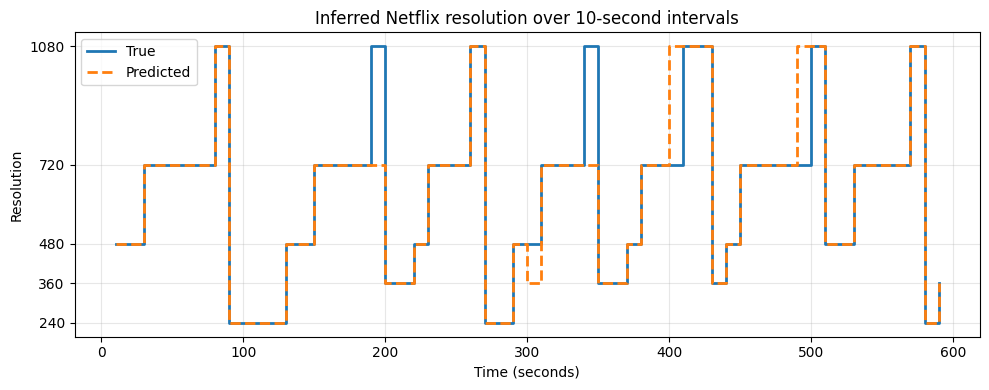

In [56]:
import matplotlib.pyplot as plt

SESSION_PATH = "data/video-qoe/netflix_session.pkl"
session = pd.read_pickle(SESSION_PATH).sort_values("relative_timestamp").reset_index(drop=True)

print("Session shape:", session.shape)
print("Time range (s):", session["relative_timestamp"].min(), "->", session["relative_timestamp"].max())

# same feature prep as Part 2 (reuse DROP_COLS / training columns)
y_true = session["resolution"].astype(int)
X_session = session.drop(columns=[c for c in DROP_COLS if c in session.columns])
X_session = pd.get_dummies(
    X_session, columns=[c for c in X_session.select_dtypes(include="object").columns]
)
X_session = X_session.reindex(columns=X.columns, fill_value=0)
X_session = X_session.fillna(X.median(numeric_only=True))

y_hat = best_model.predict(X_session)
t = session["relative_timestamp"].to_numpy()

print("Predicted resolutions:", sorted(set(y_hat)))
print("Accuracy on this session:", (y_hat == y_true).mean())

plt.figure(figsize=(10, 4))
plt.step(t, y_true, where="post", label="True", linewidth=2)
plt.step(t, y_hat, where="post", label="Predicted", linewidth=2, linestyle="--")
plt.yticks([240, 360, 480, 720, 1080])
plt.xlabel("Time (seconds)")
plt.ylabel("Resolution")
plt.title("Inferred Netflix resolution over 10-second intervals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Second model predicted resolutions: [np.int64(240), np.int64(360), np.int64(480), np.int64(720), np.int64(1080)]
Second model accuracy on this session: 0.864406779661017
First model accuracy on this session: 0.9152542372881356


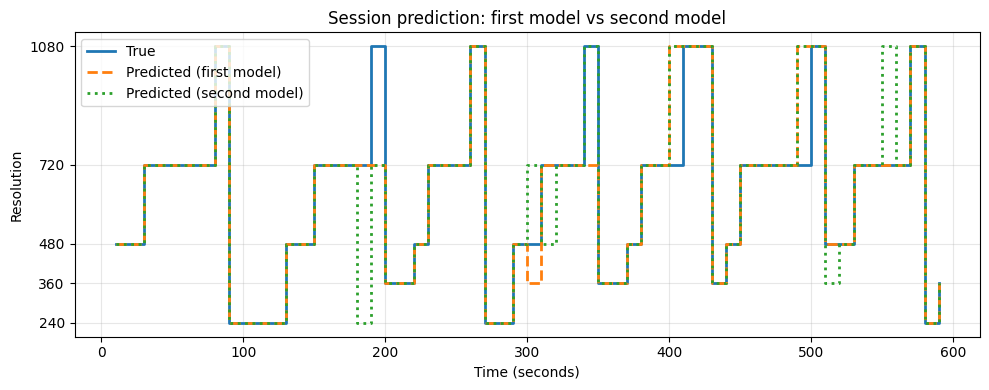

In [ ]:
# Supplement: running the same session with the second (leakage-reduced) model

# Reuse the same session prep, but align to the second model's features
X_session_second = session.drop(columns=[c for c in DROP_COLS if c in session.columns])
X_session_second = pd.get_dummies(
    X_session_second,
    columns=[c for c in X_session_second.select_dtypes(include="object").columns]
)
X_session_second = X_session_second.reindex(columns=X_no_bitrate.columns, fill_value=0)
X_session_second = X_session_second.fillna(X_no_bitrate.median(numeric_only=True))

y_hat_second = model_no_bitrate.predict(X_session_second)

print("Second model predicted resolutions:", sorted(set(y_hat_second)))
print("Second model accuracy on this session:", (y_hat_second == y_true).mean())
print("First model accuracy on this session:", (y_hat == y_true).mean())

plt.figure(figsize=(10, 4))
plt.step(t, y_true, where="post", label="True", linewidth=2)
plt.step(t, y_hat, where="post", label="Predicted (first model)", linewidth=2, linestyle="--")
plt.step(t, y_hat_second, where="post", label="Predicted (second model)", linewidth=2, linestyle=":")
plt.yticks([240, 360, 480, 720, 1080])
plt.xlabel("Time (seconds)")
plt.ylabel("Resolution")
plt.title("Session prediction: first model vs second model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()